# 16 Global Consensus Tree Context

**Methods mapping:** global consensus G-gene tree context for focal haplotype backgrounds.

This notebook summarizes the global G-gene tree used for the local tree panels and checks the focal-branch same-state recovery table used in Fig. 4.


In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, Image as IPyImage

ROOT = Path.cwd().resolve()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / 'config' / 'analysis_config.yaml').exists():
        ROOT = candidate
        break
sys.path.insert(0, str(ROOT / 'notebooks'))
import analysis_utils as au
pd.set_option('display.max_columns', 80)
pd.set_option('display.width', 160)
rel = lambda path: Path(path).relative_to(ROOT).as_posix()
ROOT
from Bio import Phylo


In [2]:
DATA_DIR, FIG_DIR = au.step_dirs('16_global_consensus_tree_context', ROOT)
INPUTS = {
    'global_tree': DATA_DIR / 'global_G_visualization_set_MFP.treefile',
    'tree_metadata': DATA_DIR / 'global_G_tree_visualization_set_metadata.csv',
    'local_subtree_summary': DATA_DIR / 'global_G_local_MRCA_subtree_summary.csv',
    'nearest_global_summary': DATA_DIR / 'focal_haplotype_nearest_global_G_consensus_summary.csv',
    'visibility_summary': DATA_DIR / 'focal_sample_branch_near_global_consensus_visibility_summary.csv',
    'visibility_by_threshold': DATA_DIR / 'focal_sample_branch_near_global_consensus_visibility_by_hamming_threshold.csv',
}
OUTPUTS = {
    'context_summary': DATA_DIR / 'global_consensus_tree_context_summary.csv',
    'figure_png': FIG_DIR / 'Figure_4_global_consensus_context.png',
    'figure_pdf': FIG_DIR / 'Figure_4_global_consensus_context.pdf',
}
display(pd.DataFrame({'input': INPUTS.keys(), 'path': [rel(p) for p in INPUTS.values()]}))
display(pd.DataFrame({'output': OUTPUTS.keys(), 'path': [rel(p) for p in OUTPUTS.values()]}))


,input,path
0,global_tree,data/processed_data/16_global_consensus_tree_c...
1,tree_metadata,data/processed_data/16_global_consensus_tree_c...
2,local_subtree_summary,data/processed_data/16_global_consensus_tree_c...
3,nearest_global_summary,data/processed_data/16_global_consensus_tree_c...
4,visibility_summary,data/processed_data/16_global_consensus_tree_c...
5,visibility_by_threshold,data/processed_data/16_global_consensus_tree_c...


,output,path
0,context_summary,data/processed_data/16_global_consensus_tree_c...
1,figure_png,results/figures/16_global_consensus_tree_conte...
2,figure_pdf,results/figures/16_global_consensus_tree_conte...


## Read Tree Context Files

The tree file is the maximum-likelihood global G-gene tree used for the local context panels. The metadata table marks global consensus records, sample consensus sequences, and focal haplotypes.


In [3]:
tree = Phylo.read(INPUTS['global_tree'], 'newick')
metadata = pd.read_csv(INPUTS['tree_metadata'])
local_summary = pd.read_csv(INPUTS['local_subtree_summary'])
nearest_summary = pd.read_csv(INPUTS['nearest_global_summary'])
visibility_summary = pd.read_csv(INPUTS['visibility_summary'])
visibility_by_threshold = pd.read_csv(INPUTS['visibility_by_threshold'])

tree_summary = pd.DataFrame({
    'tree_tips': [len(tree.get_terminals())],
    'metadata_records': [len(metadata)],
    'global_consensus_records': [int(metadata.get('record_type', pd.Series(dtype=str)).eq('global_consensus').sum())],
    'study_consensus_records': [int(metadata.get('record_type', pd.Series(dtype=str)).eq('study_consensus').sum())],
    'study_haplotype_records': [int(metadata.get('record_type', pd.Series(dtype=str)).eq('study_haplotype').sum())],
})
tree_summary.to_csv(OUTPUTS['context_summary'], index=False)

display(tree_summary)
display(local_summary)
display(visibility_summary)


,tree_tips,metadata_records,global_consensus_records,study_consensus_records,study_haplotype_records
0,1223,1223,0,109,0


,panel,target_branches,tips_total,global_consensus_representative,study_consensus,study_focal_haplotype
0,A,C4+C6,142,67,29,46
1,B,C18+C21,194,106,35,53


,dataset,branch,expected_barcode,threshold_nt,n_focal_sample_branches,n_focal_with_any_global_within_threshold,n_focal_with_same_barcode_global_within_threshold,total_global_records_any_barcode_within_threshold,total_global_records_same_barcode_within_threshold,median_min_any_global_distance_nt,median_min_same_barcode_global_distance_nt
0,United States,C18,US_C18_like,5,26,26,0,5063,0,2.0,12.0
1,United States,C21,US_C21_like,5,26,26,26,7002,5771,0.0,0.0
2,Australia,C4,AU_C4_like,5,23,23,23,8043,7212,0.0,0.0
3,Australia,C6,AU_C6_like,5,23,13,0,1174,0,5.0,NaN


## Focal-Branch Recovery Check

For each focal branch, the same-state recovery table records the number of target sample branches with a nearby global consensus sequence carrying the same core G-HVR2 state.


In [4]:
cols = [c for c in ['project', 'project_label', 'branch', 'role', 'n_focal_sample_branches', 'n_focal_with_same_barcode_global_within_threshold'] if c in visibility_summary.columns]
display(visibility_summary[cols])

display(visibility_by_threshold.head())
display(nearest_summary.head())


,branch,n_focal_sample_branches,n_focal_with_same_barcode_global_within_threshold
0,C18,26,0
1,C21,26,26
2,C4,23,23
3,C6,23,0


,dataset,project,SampleID,branch,expected_barcode,threshold_nt,n_haplotypes_in_sample_branch,has_any_global_within_threshold,has_same_barcode_global_within_threshold,min_any_global_distance_nt,min_same_barcode_global_distance_nt,global_records_within_threshold_any_barcode,global_records_within_threshold_same_barcode
0,Australia,PRJNA1037681,SRR26779971,C4,AU_C4_like,5,1,True,True,1.0,1.0,342,312
1,Australia,PRJNA1037681,SRR26779974,C4,AU_C4_like,5,1,True,True,2.0,2.0,320,296
2,Australia,PRJNA1037681,SRR26779980,C4,AU_C4_like,5,1,True,True,0.0,0.0,355,316
3,Australia,PRJNA1037681,SRR26779981,C4,AU_C4_like,5,1,True,True,0.0,0.0,355,316
4,Australia,PRJNA1037681,SRR26779985,C4,AU_C4_like,5,1,True,True,0.0,0.0,355,316


,project,TreeCluster_branch,hap_rank_in_sample,n_haplotypes,median_nearest_distance_nt,min_nearest_distance_nt,max_nearest_distance_nt,exact_global_match_n,within_1nt_global_match_n
0,PRJNA1037681,C4,1,23,0.0,0,2,17,21
1,PRJNA1037681,C6,2,23,5.0,3,8,0,0
2,PRJNA1130896,C18,2,26,2.0,2,4,0,0
3,PRJNA1130896,C21,1,26,0.0,0,1,22,26
4,PRJNA1130896,C21,3,1,0.0,0,0,1,1


## Figure

The figure file contains the global-context panels used for Fig. 4, including the local global G-tree context and the same-state recovery summary.


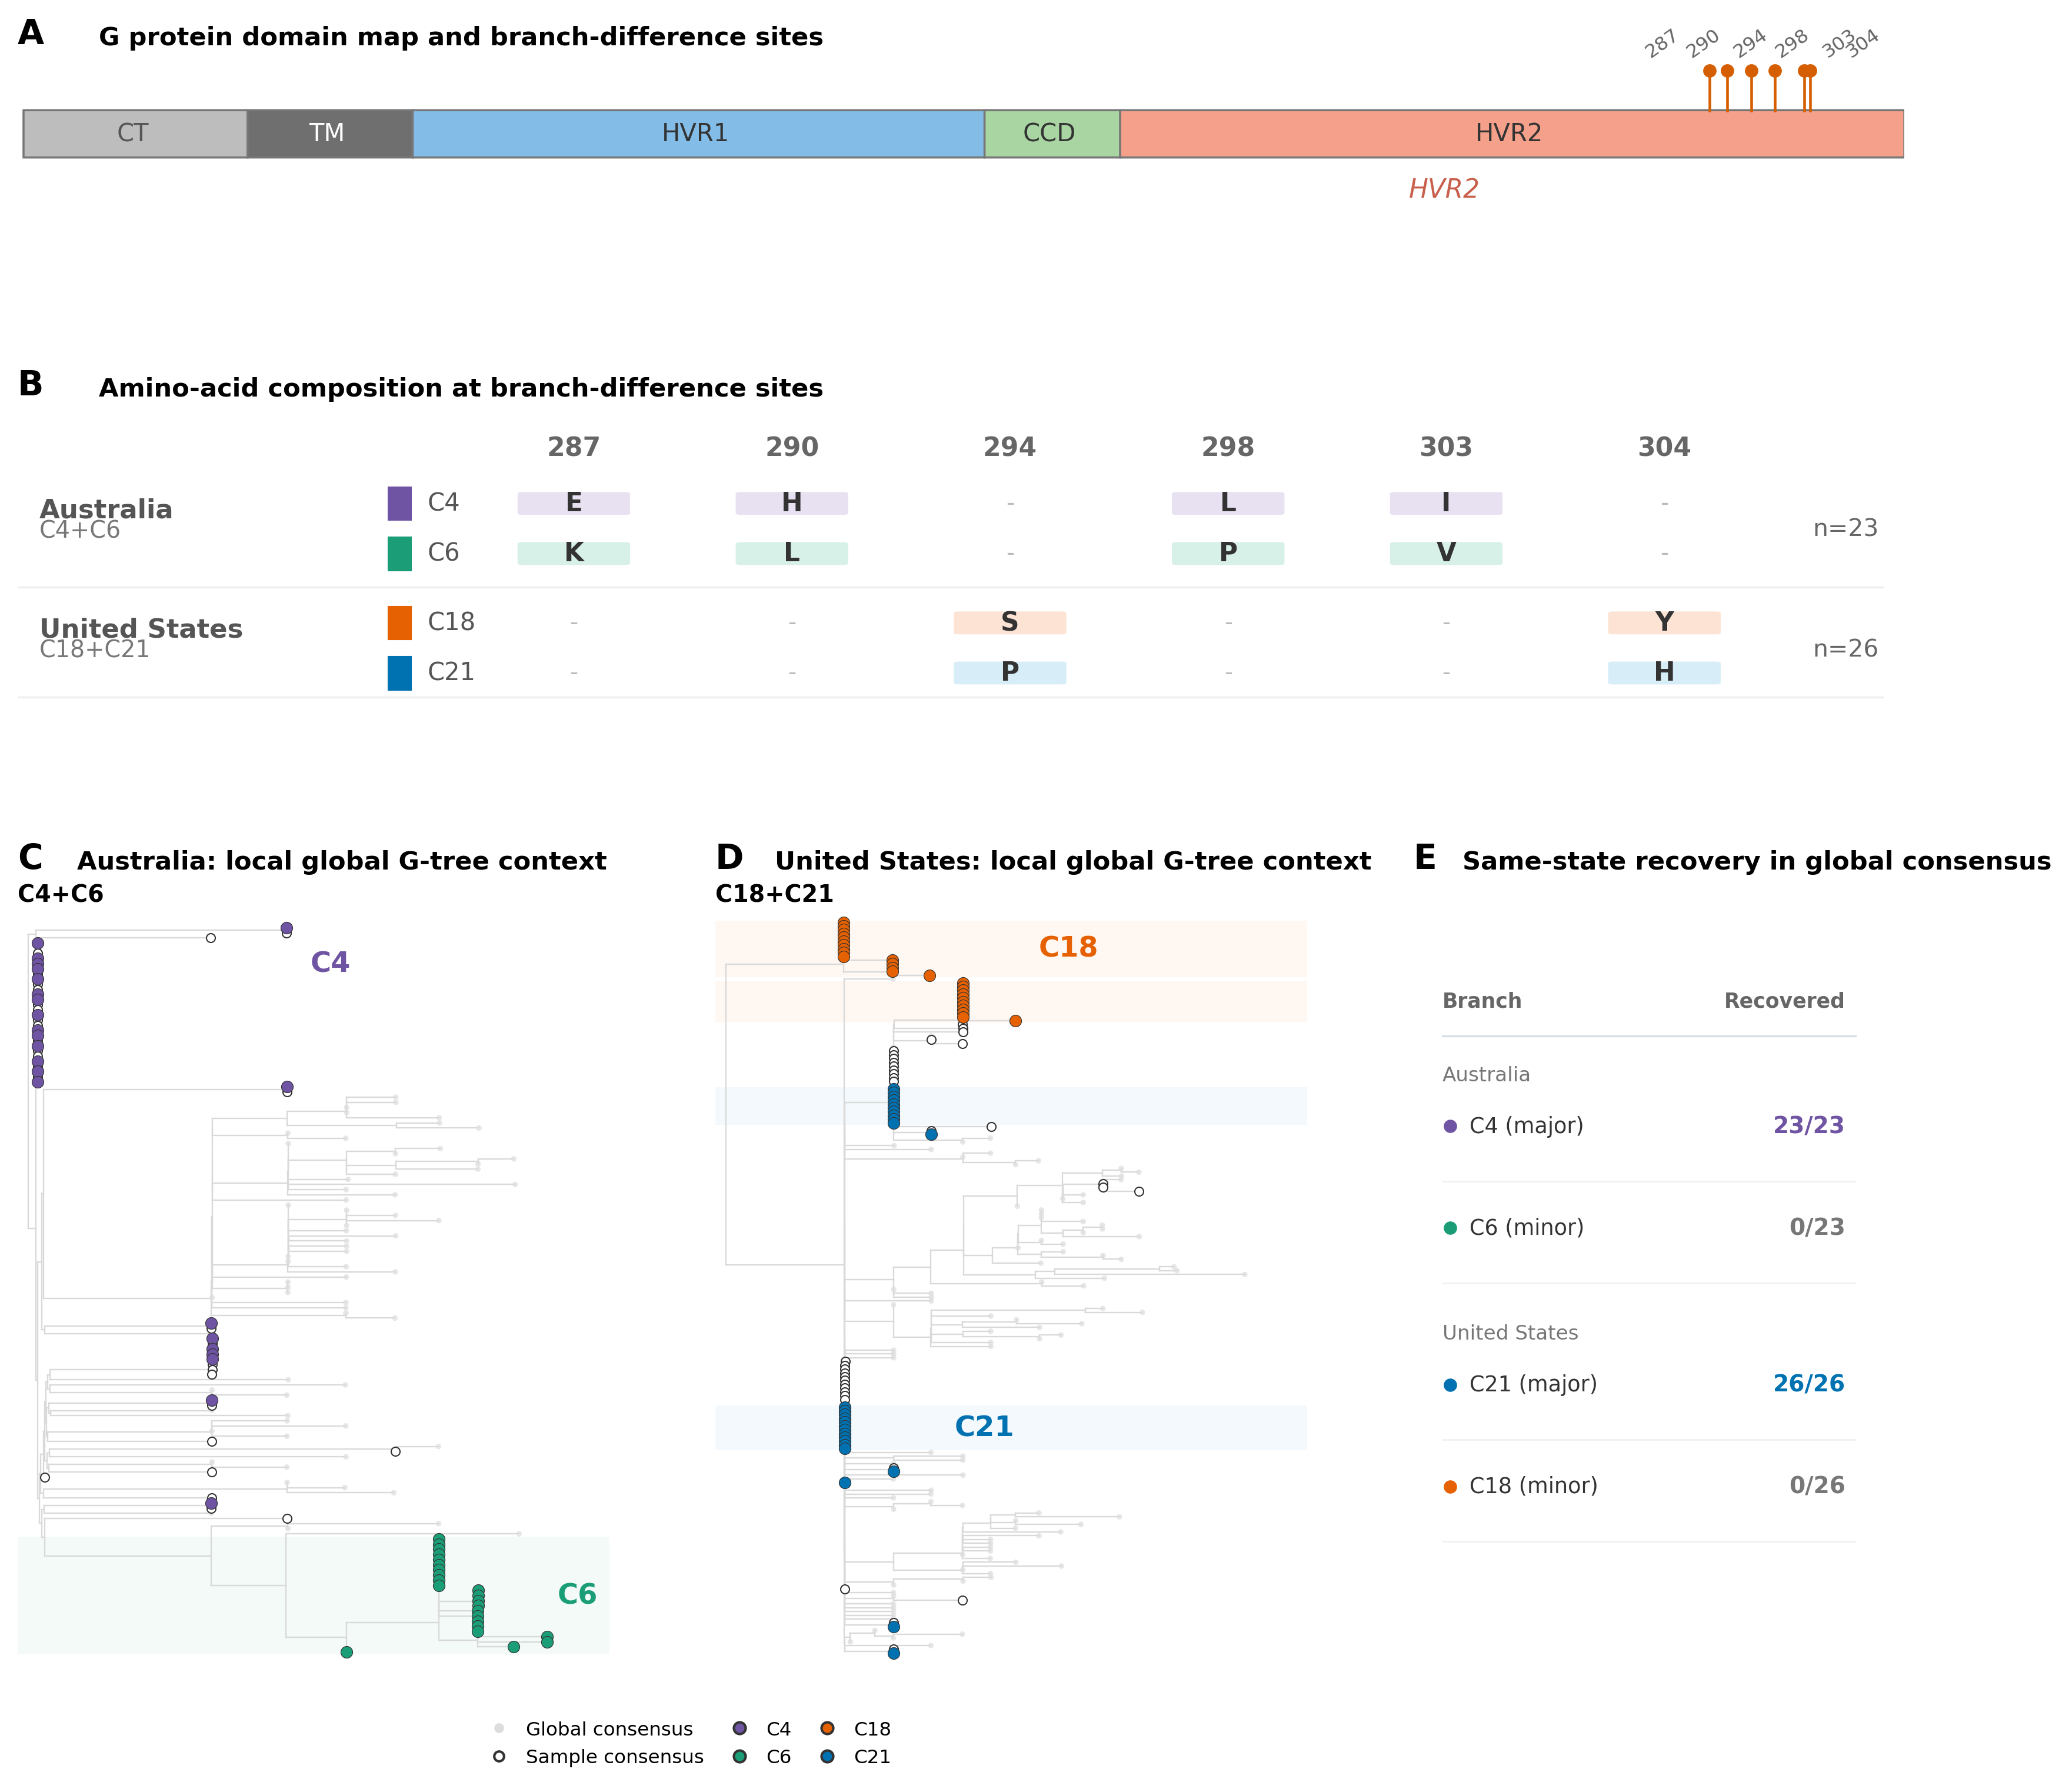

In [5]:
if OUTPUTS['figure_png'].exists():
    display(IPyImage(filename=str(OUTPUTS['figure_png']), width=900))
else:
    raise FileNotFoundError(OUTPUTS['figure_png'])
